# Session 44: Full-Information vs. Early-Warning Comparison
**Week 4 Leakage-Aware Research Conclusion**

In this notebook, we compare the predictive performance of a `RandomForestRegressor` ($n\_estimators=300$, $random\_state=42$) evaluated under two distinct feature scenarios:
1. **Full-Information Scenario:** Predictors include earlier term grades ($G1$ and $G2$).
2. **Early-Warning Scenario:** Predictors strictly exclude $G1$ and $G2$ to simulate true early intervention prior to grading.

Both models evaluate performance against final grade $G3$ using identical training and testing student splits.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Resolve project root directory
PROJECT_ROOT = Path.cwd().resolve()
for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (parent / ".git").exists():
        PROJECT_ROOT = parent
        break

DATA_DIRECTORY = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "reports" / "session44"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Output Directory:", OUTPUT_DIR)

Project Root: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml
Output Directory: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/session44


In [2]:
def load_data_scenarios():
    candidates = list((DATA_DIRECTORY / "processed").rglob("*.parquet")) + list((DATA_DIRECTORY / "processed").rglob("*.csv")) + list(DATA_DIRECTORY.rglob("student-mat.csv"))
    
    for path in candidates:
        try:
            df = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(path, sep=";" if path.suffix == ".csv" else ",")
            if df.shape[1] == 1:
                df = pd.read_csv(path, sep=",")
                
            if "G3" in df.columns:
                target = df["G3"]
                features_raw = df.drop(columns=["G3"])
                
                # Full-Information: includes G1 and G2
                X_full = pd.get_dummies(features_raw, drop_first=True, dtype=float)
                
                # Early-Warning: excludes G1 and G2
                early_cols = [c for c in features_raw.columns if c not in ["G1", "G2"]]
                X_early = pd.get_dummies(features_raw[early_cols], drop_first=True, dtype=float)
                
                # Identical student train/test splits for both scenarios
                Xtr_f, Xte_f, ytr, yte = train_test_split(X_full, target, test_size=0.20, random_state=42)
                Xtr_e, Xte_e, _, _ = train_test_split(X_early, target, test_size=0.20, random_state=42)
                
                return (Xtr_f, Xte_f), (Xtr_e, Xte_e), ytr, yte
        except Exception:
            continue
    raise FileNotFoundError("Could not locate valid student dataset files.")

(Xtr_f, Xte_f), (Xtr_e, Xte_e), ytr, yte = load_data_scenarios()
print(f"Full-Information Features Shape:  {Xtr_f.shape[1]} features")
print(f"Early-Warning Features Shape:     {Xtr_e.shape[1]} features")
print(f"Testing Observations Count:       {len(yte)} students")

Full-Information Features Shape:  41 features
Early-Warning Features Shape:     39 features
Testing Observations Count:       79 students


In [3]:
def eval_reg(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred))
    }

# Instantiate identical Random Forest regressors
rf_full = RandomForestRegressor(n_estimators=300, random_state=42)
rf_early = RandomForestRegressor(n_estimators=300, random_state=42)

# Fit both scenarios
rf_full.fit(Xtr_f, ytr)
rf_early.fit(Xtr_e, ytr)

# Generate test predictions
full_preds = rf_full.predict(Xte_f)
early_preds = rf_early.predict(Xte_e)

# Calculate evaluation metrics
full_metrics = eval_reg(yte, full_preds)
early_metrics = eval_reg(yte, early_preds)

comparison_df = pd.DataFrame([
    {"Scenario": "Full-Information (With G1 & G2)", **full_metrics},
    {"Scenario": "Early-Warning (Excluding G1 & G2)", **early_metrics}
])

print("Side-by-Side Model Scenario Results:")
display(comparison_df.round(4))

Side-by-Side Model Scenario Results:


,Scenario,MAE,RMSE,R2
0,Full-Information (With G1 & G2),1.1706,1.9747,0.8098
1,Early-Warning (Excluding G1 & G2),3.0727,3.8589,0.2738


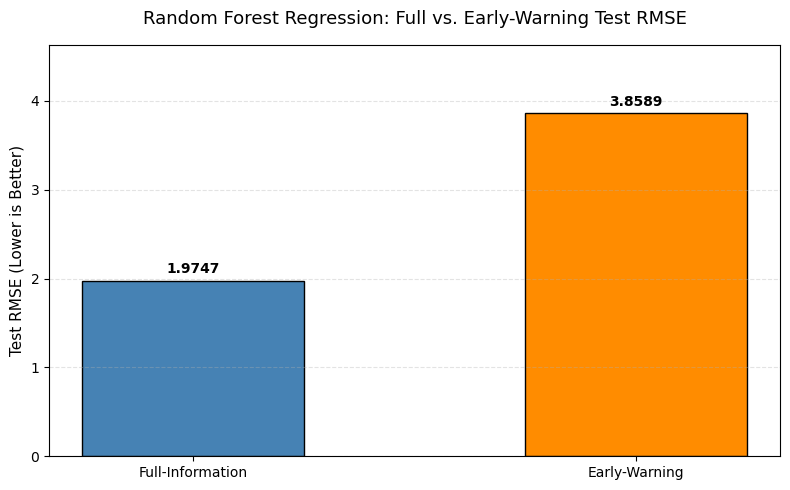

Exported artifacts cleanly to: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/session44


In [4]:
# 1. Export CSV Metrics Table
csv_output_path = OUTPUT_DIR / "full_vs_early_metrics.csv"
comparison_df.to_csv(csv_output_path, index=False)

# 2. Generate Comparison Figure
plt.figure(figsize=(8, 5))
scenarios = ["Full-Information", "Early-Warning"]
rmse_values = [full_metrics["RMSE"], early_metrics["RMSE"]]
colors = ["steelblue", "darkorange"]

bars = plt.bar(scenarios, rmse_values, color=colors, edgecolor="black", width=0.5)
plt.title("Random Forest Regression: Full vs. Early-Warning Test RMSE", fontsize=13, pad=15)
plt.ylabel("Test RMSE (Lower is Better)", fontsize=11)
plt.ylim(0, max(rmse_values) * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.35)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.05, f"{height:.4f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
figure_output_path = OUTPUT_DIR / "full_vs_early_rmse_comparison.png"
plt.savefig(figure_output_path, dpi=300, bbox_inches="tight")
plt.show()

# 3. Generate Summary Note Artifact
rmse_diff = early_metrics["RMSE"] - full_metrics["RMSE"]
r2_diff = full_metrics["R2"] - early_metrics["R2"]

note_text = f"""SESSION 44: FULL-INFORMATION VS EARLY-WARNING COMPARISON NOTE
=============================================================
Model: Random Forest Regressor (n_estimators=300, random_state=42)
Target Variable: G3 (Final Grade)

RESULTS SUMMARY:
1. Full-Information Scenario (With G1 & G2):
   - MAE:  {full_metrics['MAE']:.4f}
   - RMSE: {full_metrics['RMSE']:.4f}
   - R2:   {full_metrics['R2']:.4f}

2. Early-Warning Scenario (Excluding G1 & G2):
   - MAE:  {early_metrics['MAE']:.4f}
   - RMSE: {early_metrics['RMSE']:.4f}
   - R2:   {early_metrics['R2']:.4f}

KEY LEAKAGE-AWARE FINDINGS:
- Excluding earlier grades (G1 and G2) increases test RMSE by {rmse_diff:.4f} points and decreases R2 by {r2_diff:.4f}.
- While full-information models yield higher accuracy, including G1/G2 constitutes temporal leakage for early-warning deployment.
- The early-warning model establishes a realistic predictive baseline prior to academic term grading.
"""

note_output_path = OUTPUT_DIR / "full_vs_early_comparison_note.txt"
with open(note_output_path, "w", encoding="utf-8") as f:
    f.write(note_text)

print(f"Exported artifacts cleanly to: {OUTPUT_DIR}")

In [5]:
# Verify all required files exist
assert csv_output_path.exists(), "Missing metrics CSV artifact!"
assert figure_output_path.exists(), "Missing comparison plot PNG artifact!"
assert note_output_path.exists(), "Missing summary note TXT artifact!"
assert note_output_path.stat().st_size > 0, "Summary note artifact is empty!"

print("=" * 72)
print("SESSION 44 GITHUB DELIVERABLE COMPLETED SUCCESSFULLY")
print("=" * 72)

SESSION 44 GITHUB DELIVERABLE COMPLETED SUCCESSFULLY
